## FINAL MINI PROJECT
### Advanced Sales Dashboard System
### PROJECT GOAL

👉 Build a system that:
- Cleans data
- Analyzes data
- Shows insights
- Creates graphs
- Gives business answers

👉 This = REAL INDUSTRY PROJECT

### PROJECT NAME

👉 Smart Sales Analysis Dashboard (Python Project)

###PROJECT FEATURES
#### Data Handling
- Load CSV
- Clean data
- Handle missing values
#### Analysis
- Total revenue
- Top products
- Top cities
- Top customers
#### Visualization
- Bar chart
- Pie chart
- Histogram
#### Smart Insights (NEW)
- Best selling product
- Highest revenue city
- Cheapest product

### COMPLETE PROJECT CODE

In [12]:
# ==========================================
# 📊 Smart Sales Analysis Dashboard
# Author: Aziz Ul Haq
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

### STEP 1 — Upload file BEFORE running project

Run this cell FIRST in Colab:

In [13]:
from google.colab import files
uploaded = files.upload()

Saving sales.csv to sales (1).csv


Upload your file → sales.csv

We will see:
```
Saving sales.csv to sales.csv
```
Now the file exists in Colab memory
### STEP 2 — Confirm file exists (debug step)

Run this to see files inside Colab:


In [19]:
import os
print(os.listdir())

['.config', 'sales.csv', 'sales (1).csv', 'sample_data']


In [18]:
# ------------------------------------------
# Load Data
# ------------------------------------------
def load_data():
    try:
        df = pd.read_csv("sales.csv")
        print(" Data Loaded\n")
        return df
    except:
        print(" File not found")
        return None


✅ Data Loaded

 Cleaning Data...
 Data Cleaned

 Total Revenue: 440000

 Sales by Product:
product
Laptop    160000
Mobile    250000
Tablet     30000
Name: total, dtype: int64

 Sales by City:
city
Islamabad    160000
Karachi       30000
Lahore       250000
Name: total, dtype: int64

 Most Sold Product:
Laptop

 Top Customer:
     name product  price  quantity    city   total
4  Ayesha  Mobile  50000         3  Lahore  150000

 Cheapest Product:
name           Sara
product      Tablet
price         30000
quantity          1
city        Karachi
total         30000
Name: 2, dtype: object

 SMART INSIGHTS:
 Best Revenue City: Lahore
 Best Selling Product: Mobile


/tmp/ipykernel_21851/3163406585.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["price"].fillna(df["price"].mean(), inplace=True)
/tmp/ipykernel_21851/3163406585.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

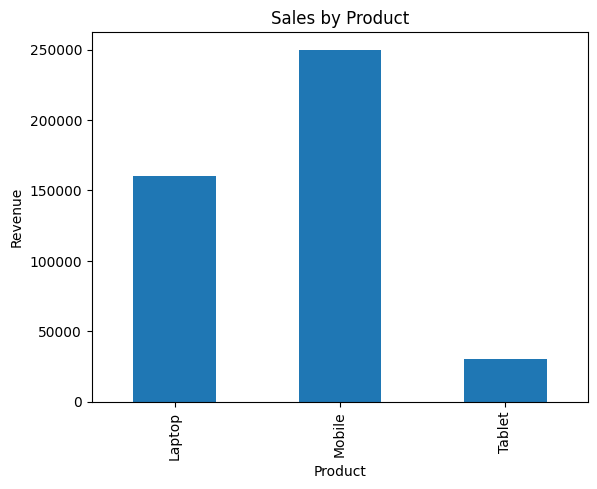

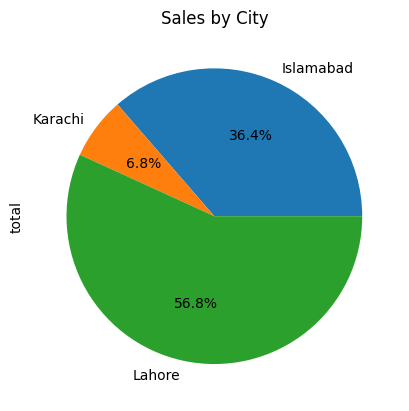

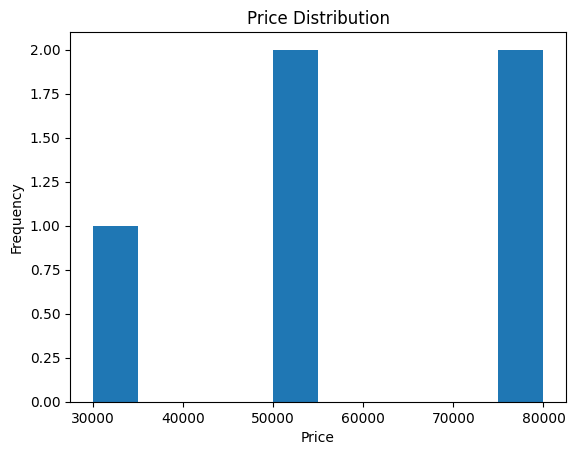

In [17]:
# ------------------------------------------
# Clean Data
# ------------------------------------------
def clean_data(df):
    print(" Cleaning Data...")

    df["price"].fillna(df["price"].mean(), inplace=True)
    df["quantity"].fillna(1, inplace=True)
    df.drop_duplicates(inplace=True)
    df.dropna(subset=["name"], inplace=True)

    df["name"] = df["name"].str.strip()
    df["city"] = df["city"].str.strip()

    df["total"] = df["price"] * df["quantity"]

    print(" Data Cleaned\n")
    return df


# ------------------------------------------
# Analysis
# ------------------------------------------
def analyze(df):

    print(" Total Revenue:", df["total"].sum())

    print("\n Sales by Product:")
    print(df.groupby("product")["total"].sum())

    print("\n Sales by City:")
    print(df.groupby("city")["total"].sum())

    print("\n Most Sold Product:")
    print(df["product"].value_counts().idxmax())

    print("\n Top Customer:")
    print(df.sort_values(by="total", ascending=False).head(1))

    print("\n Cheapest Product:")
    print(df.loc[df["price"].idxmin()])


# ------------------------------------------
# Visualization
# ------------------------------------------
def visualize(df):

    # Bar chart
    df.groupby("product")["total"].sum().plot(kind="bar")
    plt.title("Sales by Product")
    plt.xlabel("Product")
    plt.ylabel("Revenue")
    plt.show()

    # Pie chart
    df.groupby("city")["total"].sum().plot(kind="pie", autopct='%1.1f%%')
    plt.title("Sales by City")
    plt.show()

    # Histogram
    df["price"].plot(kind="hist")
    plt.title("Price Distribution")
    plt.xlabel("Price")
    plt.show()


# ------------------------------------------
# Smart Insights (INTERVIEW LEVEL)
# ------------------------------------------
def insights(df):

    best_city = df.groupby("city")["total"].sum().idxmax()
    best_product = df.groupby("product")["quantity"].sum().idxmax()

    print("\n SMART INSIGHTS:")
    print(f" Best Revenue City: {best_city}")
    print(f" Best Selling Product: {best_product}")


# ------------------------------------------
# MAIN FUNCTION
# ------------------------------------------
def main():

    df = load_data()

    if df is None:
        return

    df = clean_data(df)

    analyze(df)

    insights(df)

    visualize(df)


if __name__ == "__main__":
    main()